<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/Main_Quest/Quest01/spaceShipTitanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# 0. 데이터 로드 (Google Drive 경로)
# -------------------------------

from google.colab import drive
drive.mount('/content/drive')


common_path = "/content/drive/MyDrive/data/kaggle/"
train_path = common_path + "spaceshipTitanic/train.csv"
test_path  = common_path + "spaceshipTitanic/test.csv"
print(train_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/data/kaggle/spaceshipTitanic/train.csv
keggle


In [15]:
print(f'train data dim : {train.shape}')
print(f'train data dim : {test.shape}')
print(train.columns)
print(len(train.columns))

train data dim : (8693, 14)
train data dim : (4277, 13)
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
14


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [11]:
# 결합 (전처리 통일)
data = pd.concat([train, test], axis=0).reset_index(drop=True)

In [16]:
print(f'train data dim : {data.shape}')
print(data.columns)
print(len(data.columns))
data.head()

train data dim : (12970, 14)
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
14


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [17]:
# -------------------------------
# 1. Feature Engineering
# -------------------------------

spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

# 소비 합계
data['TotalSpend'] = data[spend_cols].sum(axis=1)

# 그룹 - PassengerId데이터에 그룹까지 나눠져있슴.
data['Group'] = data['PassengerId'].str.split('_').str[0]
data['GroupSize'] = data.groupby('Group')['PassengerId'].transform('count')

# Cabin 분해 - Cabin 데이터 3등분
data[['Deck','Num','Side']] = data['Cabin'].str.split('/', expand=True)

data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpend,Group,GroupSize,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,0001,1,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,0002,1,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,0003,2,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,0003,2,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,0004,1,F,1,S


In [19]:
# (1) 소비 → 0
data[spend_cols] = data[spend_cols].fillna(0)

# (2) CryoSleep → 행동 기반 + 타입 명시
data['CryoSleep'] = data['CryoSleep'].fillna(data['TotalSpend'] == 0)
data['CryoSleep'] = data['CryoSleep'].astype(bool)

# (3) Cabin → 그룹 기반
data['Cabin'] = data.groupby('Group')['Cabin'].transform(
    lambda x: x.ffill().bfill()
)

# 다시 분해
data[['Deck','Num','Side']] = data['Cabin'].str.split('/', expand=True)

# (4) HomePlanet → 그룹 → Deck
data['HomePlanet'] = data.groupby('Group')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

deck_planet_map = {
    'A': 'Europa', 'B': 'Europa', 'C': 'Europa',
    'D': 'Mars',
    'E': 'Earth', 'F': 'Earth', 'G': 'Earth'
}

data['HomePlanet'] = data.apply(
    lambda row: deck_planet_map.get(row['Deck'], 'Earth')
    if pd.isna(row['HomePlanet']) else row['HomePlanet'],
    axis=1
)

# (5) Destination
data['Destination'] = data['Destination'].fillna(
    data.groupby('HomePlanet')['Destination'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'TRAPPIST-1e'
    )
)

# (6) Age
data['Age'] = data.groupby('Group')['Age'].transform('mean')
data['Age'] = data['Age'].fillna(data['Age'].median())

# (7) VIP → 타입 명시
data['VIP'] = data['VIP'].fillna(False).astype(bool)
data.loc[data['TotalSpend'] > 1000, 'VIP'] = True

# (8) Deck / Side
for col in ['Deck','Side']:
    data[col] = data.groupby('Group')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Unknown')
    )

/tmp/ipykernel_7148/999073323.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.ffill().bfill()


In [20]:
# -------------------------------
# 3. 모델용 데이터 구성
# -------------------------------

features = [
    'CryoSleep','VIP','HomePlanet','Destination',
    'Age','TotalSpend','GroupSize','Deck','Side'
]

data_model = data[features]

# One-hot encoding
data_model = pd.get_dummies(data_model)

In [21]:
# -------------------------------
# 4. train / test 분리
# -------------------------------

train_X = data_model.iloc[:len(train)]
test_X  = data_model.iloc[len(train):]

train_y = train['Transported']

In [22]:
# -------------------------------
# 5. 검증
# -------------------------------

X_tr, X_val, y_tr, y_val = train_test_split(
    train_X, train_y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_tr, y_tr)

pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, pred))



Validation Accuracy: 0.7469810235767682


In [24]:
# -------------------------------
# 6. 제출 파일 생성
# -------------------------------

test_pred = model.predict(test_X)

submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": test_pred
})

submission.to_csv(
    "/content/drive/MyDrive/data/kaggle/spaceshipTitanic/submission.csv",
    index=False
)

print("submission.csv 저장 완료")

submission.csv 저장 완료


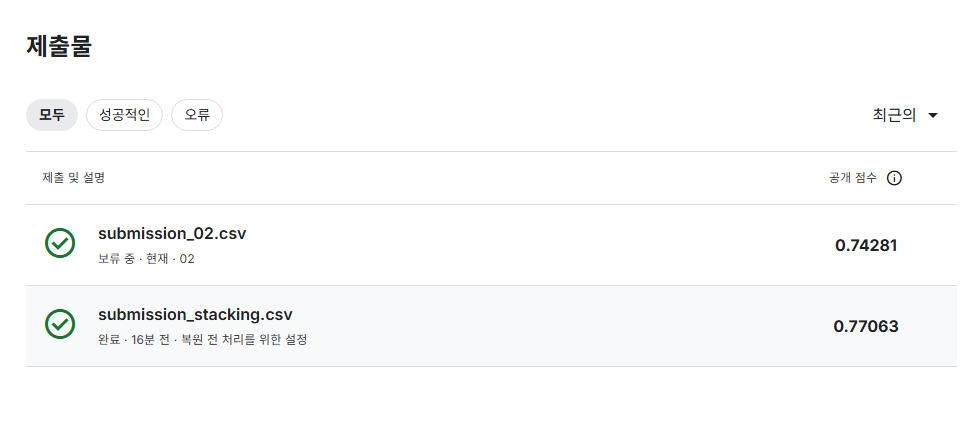